In [6]:
import pandas as pd

df=pd.read_csv("mnist_test.csv")
print("Loaded")

Loaded


In [7]:
print(df.head(10))
print(df.tail(10))
print(df.info())
print(df.describe())      

   label  1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  ...  28x19  28x20  \
0      7    0    0    0    0    0    0    0    0    0  ...      0      0   
1      2    0    0    0    0    0    0    0    0    0  ...      0      0   
2      1    0    0    0    0    0    0    0    0    0  ...      0      0   
3      0    0    0    0    0    0    0    0    0    0  ...      0      0   
4      4    0    0    0    0    0    0    0    0    0  ...      0      0   
5      1    0    0    0    0    0    0    0    0    0  ...      0      0   
6      4    0    0    0    0    0    0    0    0    0  ...      0      0   
7      9    0    0    0    0    0    0    0    0    0  ...      0      0   
8      5    0    0    0    0    0    0    0    0    0  ...      0      0   
9      9    0    0    0    0    0    0    0    0    0  ...      0      0   

   28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
0      0      0      0      0      0      0      0      0  
1      0      0      0      0      0      0

In [8]:
print(df.shape)

(10000, 785)


In [9]:
print(df.isnull().sum())

label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Length: 785, dtype: int64


In [10]:
print(df["label"].value_counts())

label
1    1135
2    1032
7    1028
3    1010
9    1009
4     982
0     980
8     974
6     958
5     892
Name: count, dtype: int64


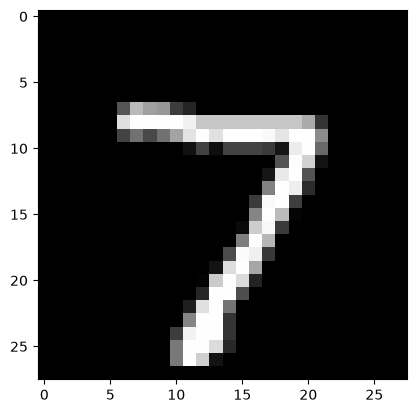

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.imshow(df.iloc[0,1:].values.reshape(28,28), cmap="gray")

In [13]:
x = df.drop("label",axis=1)
y = df["label"]

from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(8000, 784)
(8000,)
(2000, 784)
(2000,)


In [14]:
print(x_train.head(5))
print(y_train.head(5))
print(x_test.head(5))
print(y_test.head(5))

      1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  1x10  ...  28x19  28x20  \
9254    0    0    0    0    0    0    0    0    0     0  ...      0      0   
1561    0    0    0    0    0    0    0    0    0     0  ...      0      0   
1670    0    0    0    0    0    0    0    0    0     0  ...      0      0   
6087    0    0    0    0    0    0    0    0    0     0  ...      0      0   
6669    0    0    0    0    0    0    0    0    0     0  ...      0      0   

      28x21  28x22  28x23  28x24  28x25  28x26  28x27  28x28  
9254      0      0      0      0      0      0      0      0  
1561      0      0      0      0      0      0      0      0  
1670      0      0      0      0      0      0      0      0  
6087      0      0      0      0      0      0      0      0  
6669      0      0      0      0      0      0      0      0  

[5 rows x 784 columns]
9254    9
1561    4
1670    5
6087    5
6669    6
Name: label, dtype: int64
      1x1  1x2  1x3  1x4  1x5  1x6  1x7  1x8  1x9  1x

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model=DecisionTreeClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

accuracy=accuracy_score(y_test,y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.794


In [18]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

select = SelectKBest(score_func=chi2, k=300)

x_train = select.fit_transform(x_train, y_train)
x_test = select.transform(x_test)

In [21]:
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

Accuracy: 0.793
[[175   1   3   4   3   6   7   1   1   2]
 [  0 203   1   2   0   2   1   1   4   2]
 [  4   4 162  11   2   4   5  12   4   5]
 [  1   0  11 155   5  23   3   3   3   4]
 [  1   2   8   2 152   3   9   5   5  28]
 [  2   1   1  13   0 135   9   4   6   3]
 [  5   0   3   1   6   4 164   4   8   5]
 [  2   0  11   4   5   1   0 160   0   4]
 [  0   5   4   9   5   9   4   3 137  10]
 [  1   1   5   8  19   7   2   5   7 143]]
              precision    recall  f1-score   support

           0       0.92      0.86      0.89       203
           1       0.94      0.94      0.94       216
           2       0.78      0.76      0.77       213
           3       0.74      0.75      0.74       208
           4       0.77      0.71      0.74       215
           5       0.70      0.78      0.73       174
           6       0.80      0.82      0.81       200
           7       0.81      0.86      0.83       187
           8       0.78      0.74      0.76       186
           9